# **E-commerce Churn Analysis**

### **Tabla de Contenidos**

<span style="color:green">**Fase 1: Fundamentos y Preparación de Datos**</span>

* Carga de Librerías
* Inportación de datasets
* Unión de dataframes
* Limpieza de Datos y Tratamiento de Nulos

<span style="color:green">**Fase 2: Ingeniería de Variables**</span>

* Construcción de la Matriz RFM (Recency, Frequency, Monetary)
* Definición de la Variable Objetivo Churn

<span style="color:green">**Fase 3: Análisis Exploratorio de Datos (EDA)**</span>

* Análisis Exploratorio de Datos (EDA)

## **Fase 1: Fundamentos y Preparación de Datos**

In [15]:
# =========================================================
# CARGA DE LIBRERÍAS
# =========================================================

# Librerías Base y Sistema
import os
import warnings
warnings.filterwarnings('ignore') # Ignorando warnings para visual más limpia

# Manipulación de Datos, Matemáticas y Tiempo
import pandas as pd
import numpy as np
import datetime as dt

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para el EDA
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [16]:
# =========================================================
# IMPORTACIÓN DE DATASETS
# =========================================================

file_path = '../data/raw/online_retail_II.xlsx'

print("Cargando Year 2009-2010...")
df_1 = pd.read_excel(file_path, sheet_name= 'Year 2009-2010') 

print("Cargando Year 2010-2011...")
df_2 = pd.read_excel(file_path, sheet_name= 'Year 2010-2011') 

print("-" * 50)
print(f"Year 2009-2010 Tamaño: {df_1.shape}")
print(f"Year 2010-2011 Tamaño: {df_2.shape}")
print("-" * 50)

Cargando Year 2009-2010...
Cargando Year 2010-2011...
--------------------------------------------------
Year 2009-2010 Tamaño: (525461, 8)
Year 2010-2011 Tamaño: (541910, 8)
--------------------------------------------------


In [17]:
# =========================================================
# UNIÓN DE DATAFRAMES (CONCATENADO)
# =========================================================

print("Apilando los dos periodos en un solo Master DataFrame...")
print("-" * 50)

# Apilado vertical de ambos df 
df_master = pd.concat([df_1, df_2], ignore_index=True) #ignore_index=True evita indices duplicados

print(f"df_master Tamaño: {df_master.shape}")
print("-" * 50)

# Estructura del df
print("Información general de df_master:")
print("-" * 50)
df_master.info()
print("-" * 50)

# Visualización
df_master.head()

Apilando los dos periodos en un solo Master DataFrame...
--------------------------------------------------
df_master Tamaño: (1067371, 8)
--------------------------------------------------
Información general de df_master:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
---------------------

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Se han concatenado ambas hojas de los diferentes periodos del dataframe teniendo como resultado un dataframe maestro de `1067371` registros, además se han identificado las siguientes detalles:

1. **Valores Nulos en `Customer ID`**: 
   - Aproximadamente el 22% de las transacciones no tienen un ID de cliente asociado, para churn se necesita el historial individual de cada cliente, por lo cuál estos registros nulos nno serán utiles para el modelo posteriormente, por lo cuál se **eliminarán los registros nulos**


2. **Data Types**:
   - `Customer ID` aparece como `float64`. luego de eliminar los nulos se cambiará a string ya que es una variable categórica.

3. **`Invoices` y `Quantity`**
   - Al observar con detalle la columna `Invoice` cuándo el valor comienza con una letra *C* al parecer corresponde a una devolución o algo similar, ya que al observar paralelamente los valores en `Quantity` coincide con valores negativos, esto podría distorsionar el historial del cliente y posteriormente el entrenamiento de algún modelo. 

In [18]:
# =========================================================
# LIMPIEZA DE DATOS Y TRATAMIENTO DE NULOS
# =========================================================

# Conteo de filas antes de la limpieza
filas_originales = df_master.shape[0]

# Eliminar registros nulos en la variable Customer ID
df_clean = df_master.dropna(subset=['Customer ID']).copy()

# Corrección de Data Types: Customer ID de float a int y luego a string
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)

# Filtrado por Invoices que NO empiezan con 'C'
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Forzar Cantidad y Precio a que sean estrictamente positivos
# df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Resumen
filas_finales = df_clean.shape[0] # Conteo de filas después de la limpieza
porcentaje_retenido = (filas_finales / filas_originales) * 100

print(f"Filas originales: {filas_originales:,}")
print(f"Filas tras limpieza: {filas_finales:,}")
print(f"Porcentaje de datos retenidos para el modelo: {porcentaje_retenido:.2f}%")
print("-" * 50)
print("Vista previa del dataset limpio:")
display(df_clean.head())

Filas originales: 1,067,371
Filas tras limpieza: 805,620
Porcentaje de datos retenidos para el modelo: 75.48%
--------------------------------------------------
Vista previa del dataset limpio:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


Se obtiene un dataframe limpio de ruido, donde se ha descartado aproxumadamente un 25% de los registros, se han eliminado los registros nulos que no poseían ID de cluente y también los invouces que corresponden a posibles devoluciones. 

## **Fase 2: Ingeniería de Variables**

In [19]:
# =========================================================
# CONSTRUCCIÓN DE LA MATRIZ RECENCY, FREQUENCY, MONETARY
# =========================================================

# Se crea variable para saber el ingreso total por cada transacción
df_clean['Total_Revenue'] = df_clean['Quantity'] * df_clean['Price']

# Definir la Fecha de Corte para recency desde un día después de la ultima transacción
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Fecha de corte para el análisis: {snapshot_date.date()}")

# Agrupación para crear el perfil RFM para cada Cliente
df_rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Días desde la última compra, busca la ultima compra y le resta la fecha de corte
    'Invoice': 'nunique',                                   # Total de compras distintas, contabiliza las invoices por fecha
    'Total_Revenue': 'sum'      # Gasto total histórico, sumatoria total de las transacciones por cliente
}).reset_index()

# Renombrando para mejor visualización
df_rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'Total_Revenue': 'Monetary'
}, inplace=True)

print("-" * 50)
print(f"Total de clientes identificados: {df_rfm.shape[0]:,}")
print("-" * 50)

print("Vista previa del RFM")
display(df_rfm.head())

Fecha de corte para el análisis: 2011-12-10
--------------------------------------------------
Total de clientes identificados: 5,881
--------------------------------------------------
Vista previa del RFM


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


Se identifican **5,881 clientes únicos** en un dataframe que consolida recency, frequency y monetary. Representando de mejor manera los comportamientos de compra de los usuarios.

* Como ejemplo puedo comparar el cliente ubicado en la fila 0 que presenta un total de gasto `Monetary` de **77556.46**, sin embargo su ultima compra `Recency`fué hace 326 días; y el cliente de la fila 1 que su `Monetary` es de **5633.32** y su `Recency` fué hace solo 2 días, aqui se puede observar que es muy probable que el cliente 0 haya fugado, sin embargo es necesario poder definir desde cuántos días de ausencia se podría considerar como tal.

Resumen estadístico de los días de inactividad (Recency):


count    5881.000000
mean      201.457745
std       209.474135
min         1.000000
25%        26.000000
50%        96.000000
75%       380.000000
max       739.000000
Name: Recency, dtype: float64

--------------------------------------------------


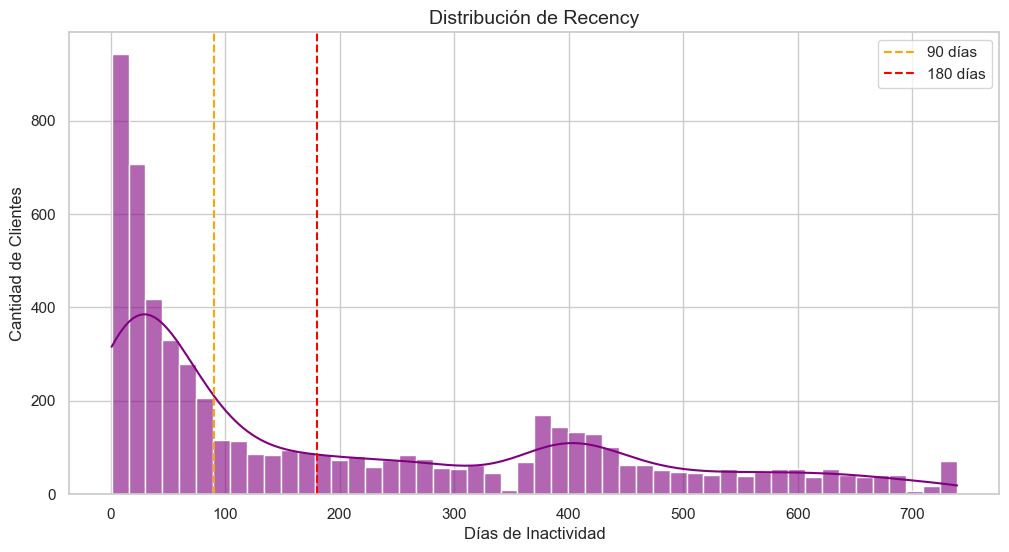

In [20]:
# =========================================================
# DEFINICIÓN DE LA VARIABLE OBJETIVO CHURN
# =========================================================

# Estadísticas descriptivas de recency
print("Resumen estadístico de los días de inactividad (Recency):")
display(df_rfm['Recency'].describe())
print("-" * 50)

# Visualización de la distribución
plt.figure(figsize=(12, 6))
sns.histplot(df_rfm['Recency'], bins=50, kde=True, color='purple', alpha=0.6)
plt.title('Distribución de Recency', fontsize=14)
plt.xlabel('Días de Inactividad', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Lineas de referencia 3 y 6 meses "posibles rangos de riesgos"
plt.axvline(x=90, color='orange', linestyle='--', label='90 días')
plt.axvline(x=180, color='red', linestyle='--', label='180 días')
plt.legend()
plt.show()

* Al observar los resultados, la media `mean` de clientes tarda *96* días es decir antes de los 3 meses regresan
* También se destaca en el gráfico un alza en la actividad posterior a los 300 días lo que se valida observando que el tercer qartil `75%` corresponde a **380** días indicando que este **25%** de clientes tarda más de un año en volver a comprar indicando **estacionalidad**, por esto el umbral de churn no debería ser menor a **365** días    

In [21]:
umbral_churn = 365

# Si Recency > 180, 1, sino  0
df_rfm['Churn'] = np.where(df_rfm['Recency'] > umbral_churn, 1, 0)

print("-" * 50)
print(f"Variable 'Churn' usando un umbral de > {umbral_churn} días.")
print("-" * 50)
print("Distribución de Clases:")
print(df_rfm['Churn'].value_counts(normalize=True).round(4) * 100)

--------------------------------------------------
Variable 'Churn' usando un umbral de > 365 días.
--------------------------------------------------
Distribución de Clases:
Churn
0    72.61
1    27.39
Name: proportion, dtype: float64


* Para evitar penalizar este comportamiento estacional y etiquetarlo erróneamente como pérdida, **se establece el umbral definitivo de Churn en 365 días**.
* Existe un leve desbalance de clases `Retenidos` *72.61%* vs `Churn` *27.39%*, no debería presentar problemas pata el entrenamiento inicial de los modelos predictivos.

## **Fase 3: Análisis Exploratorio de Datos (EDA)**

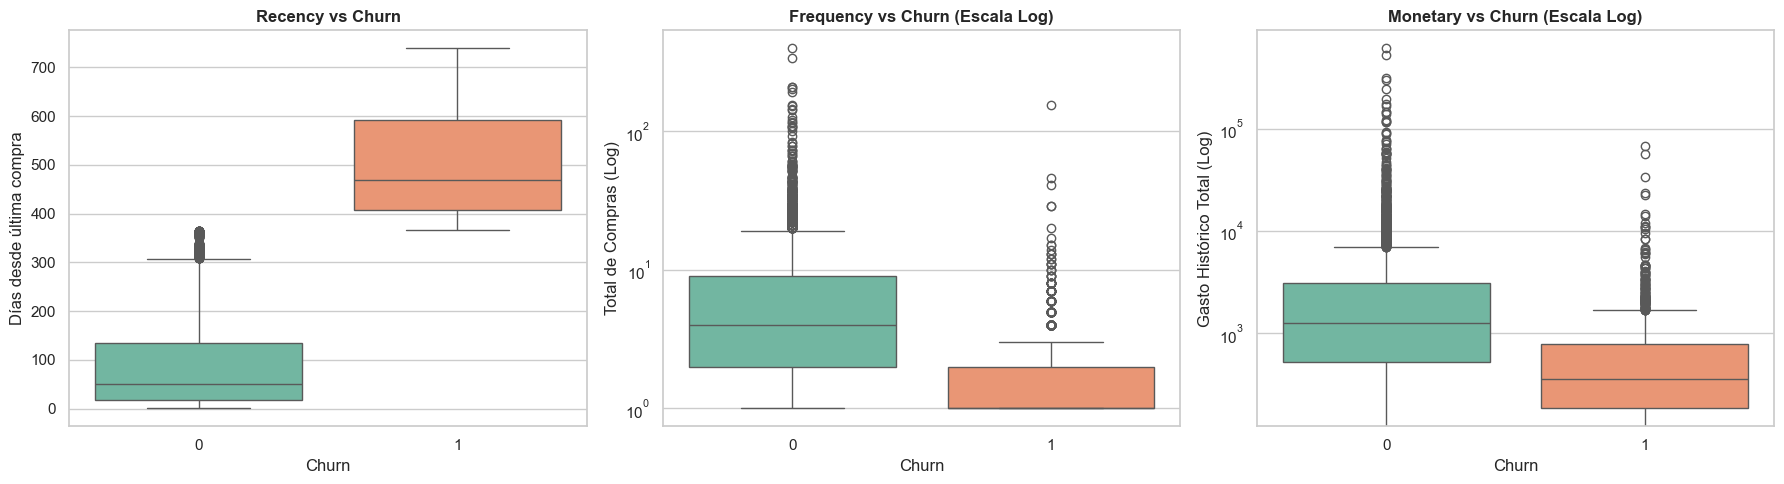

In [22]:
# =========================================================
# ANÁLISIS EXPLORATORIO BIVARIADO (RFM vs CHURN)
# =========================================================

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recencia vs Churn
sns.boxplot(data=df_rfm, x='Churn', y='Recency', palette='Set2', ax=axes[0])
axes[0].set_title('Recency vs Churn', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Días desde última compra')

# Frecuencia vs Churn con escala logaritmica debido a la diferencia alta que puede existir
sns.boxplot(data=df_rfm, x='Churn', y='Frequency', palette='Set2', ax=axes[1])
axes[1].set_yscale('log') 
axes[1].set_title('Frequency vs Churn (Escala Log)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total de Compras (Log)')

# Monetario vs Churn
sns.boxplot(data=df_rfm, x='Churn', y='Monetary', palette='Set2', ax=axes[2])
axes[2].set_yscale('log')
axes[2].set_title('Monetary vs Churn (Escala Log)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Gasto Histórico Total (Log)')

plt.tight_layout()
plt.show()

* **Recency vs Churn:** Se observa que la caja de Churn ha quedado bien delimitada comenzando desde el umbral de **365 días**. En los clientes retenidos, la mediana se encuentra cerca de los **50 días**, operando en un rango típico. Destaca un grupo de clientes (outliers) que están muy cerca de los 365 días, los cuales deben ser clasificados como **"Clientes en Riesgo"**.
* **Frequency vs Churn:** La mediana de los clientes fugados está casi en el suelo, lo que indica que **generalmente no hacen más que una sola compra**. En contraste, los clientes retenidos tienen una media bastante mayor de recompras, observándo que han realizado más de 100 pedidos.
* **Monetary vs Churn:** Los clientes que se fugan gastan muy poco dinero en la tienda antes de irse. Esto indica que **son clientes que hacen una compra de prueba y no repiten**. Los retenidos, por el contrario, concentran a los clientes de alto Valor.

**La empresa tiene un núcleo potente de clientes leales. Para reducir el Churn, la estrategia no debe centrarse en retener a los antiguos, sino en mejorar la experiencia de la primera compra, evitando así que el cliente pruebe, no le guste y se vaya.**

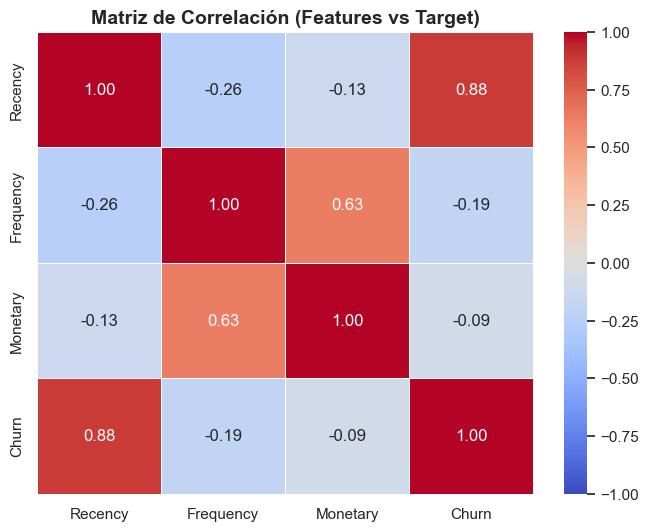

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN
# =========================================================

plt.figure(figsize=(8, 6))
# Correlación de Pearson
correlation_matrix = df_rfm[['Recency', 'Frequency', 'Monetary', 'Churn']].corr()

# Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Features vs Target)', fontsize=14, fontweight='bold')
plt.show()

* **Recency vs Churn**: se observa una correlación positiva altísima de **0.88**. Esto es completamente lógico ya que la etiqueta de churn fue construida a partir del umbral de recency (365 días). Por lo tanto, dejar esta variable para entrenar el modelo generaría `data leakage`, haciendo que el algoritmo haga trampa en lugar de aprender patrones.
* **Frequency vs Churn**: se observa una correlación negativa de **-0.19**, lo que indicaría que a medida que el cliente aumenta su cantidad de compras, la probabilidad de que se fugue disminuye.
* **Monetary vs Churn**: se presenta una correlación negativa más leve de **-0.09**. Esto muestra que, si bien el gasto histórico ayuda a reducir el abandono, no tiene tanta fuerza como la frecuencia.